In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import backtestPairs, calculatePairMetrics
# from MODELS.teamInfo import *


In [92]:
import joblib


# Load NGBoost mean and variance models
mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST_25.pkl')
variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST_25.pkl')
calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_TEST_25.pkl')

# mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST_26.pkl')
# variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST_26.pkl')
# calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_TEST_26.pkl')

models = {
    'mean': mean_model,
    'variance': variance_model,
    'calibration_factor': calibration_factor
}

features = joblib.load('../MODELS/SAVED_MODELS/feature_list.pkl')

print(f"Loaded NGBoost models with calibration factor: {calibration_factor}")
print(f"Number of features: {len(features)}")

Loaded NGBoost models with calibration factor: 1
Number of features: 127


In [93]:
pd.set_option('display.max_columns', None)

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
# s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
# s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')
# df = s26
df = s25

In [98]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'prizepicks') &  (backtestData['CATEGORY'] == 'player_points')]
backtestData.sample(5)


/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_25144/2718787215.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
79339,79339,79339,79339,Kyle Kuzma,player_points,prizepicks,over,19.5,-137,Minnesota Timberwolves,Milwaukee Bucks,NaN,NaN,2025-02-13,game,19.0,100.0,over
138241,138241,138241,43162,Zaccharie Risacher,player_points,prizepicks,under,12.5,-137,Brooklyn Nets,Atlanta Hawks,NaN,NaN,2025-03-16,game,12.5,-103.0,under
39787,39787,39787,39787,Harrison Barnes,player_points,prizepicks,over,11.0,-137,Chicago Bulls,San Antonio Spurs,a4bb1101bac62c47c838f65850145f3f,2025-01-07T01:10:00Z,2025-01-06,NaN,NaN,NaN,over
20016,20016,20016,20016,Desmond Bane,player_points,prizepicks,under,16.5,-137,Memphis Grizzlies,New Orleans Pelicans,057e5aae2a26f423eaf44d3e6bcab7eb,2024-11-29T22:10:00Z,2024-11-29,NaN,NaN,NaN,under
192988,192988,192988,113253,Dennis Schroder,player_points,prizepicks,under,10.5,-137,Detroit Pistons,Milwaukee Bucks,NaN,NaN,2025-04-11,game,10.5,-102.0,under


In [95]:
# backtestData= pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/s26props.csv')
# s26_other = pd.read_csv('../DATA/CSV_FILES/PROP_DATA/PLAYER_LINES/NBA_DFS_20251106.csv')
# s26_other1 = pd.read_csv('../DATA/CSV_FILES/PROP_DATA/PLAYER_LINES/NBA_DFS_20251107.csv')
# backtestData = pd.concat([backtestData, s26_other, s26_other1])

# backtestData = backtestData[(backtestData['BOOKMAKER'] == 'Underdog') &  
#                             (backtestData['CATEGORY'] == 'player_points')]
# backtestData.rename(columns={'COMMENCE_TIME': 'GAME_DATE', 'OVER/UNDER': 'SIDE'}, inplace=True)
# backtestData

In [ ]:
date = '2025-10-31'

results = backtestPairs(
    data=s25,
    backtestData=backtestData,
    gameDate=date,
    models=models,  
    features=features,
    edge_threshold=0.30, 
    top_n=5, 
    variance_inflation=1.1, 
    distribution_type='t', stat_col='PTS', 
    use_monte_carlo=True, n_simulations=10000, max_kelly=0.25, stake=10)

# results = results[(results['SIGMA FLAG 1'] != 'High') & (results['SIGMA FLAG 2'] != 'High')]

# Comprehensive results analysis
if not results.empty:
    print("=" * 60)
    print("PAIR BETTING RESULTS ANALYSIS")
    print("=" * 60)
    
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Calculate profit/loss
    total_profit = results['pair_profit'].sum() * 3
    avg_profit = results['pair_profit'].mean() * 3
    
    print(f"Total Bets: {total_bets}")
    print(f"Wins: {total_wins}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total Profit: ${total_profit:.2f}")
    print(f"Average Profit per Bet: ${avg_profit:.2f}")

results

Starting backtest for pairs on 2025-10-31
Time taken for pairs: 0.5420081615447998 seconds
Time taken for sorting: 0.5432260036468506 seconds
Time taken for dropping duplicates: 0.5455050468444824 seconds
Time taken for iterating over evData: 0.545539140701294 seconds
Time taken for backtest_results: 0.5475690364837646 seconds
PAIR BETTING RESULTS ANALYSIS
Total Bets: 5
Wins: 3
Win Rate: 60.00%
Total Profit: $120.00
Average Profit per Bet: $24.00


,NAME 1,NAME 2,LINE 1,LINE 2,PREDICTION 1,PREDICTION 2,MODEL SIDE 1,MODEL SIDE 2,PROB 1,PROB 2,PROB BOTH,EDGE 1,EDGE 2,COMBINED EDGE,EV$,KELLY FULL,RECOMMENDATION,INTERVAL WIDTH 1,INTERVAL WIDTH 2,SIGMA 1,SIGMA 2,SIGMA FLAG 1,SIGMA FLAG 2,EXPECTED ROI,SIMULATION METHOD,actual1,actual2,leg1_won,leg2_won,pair_won,pair_recommendation,pair_profit,selection,date
0,Aaron Nesmith,Tyrese Maxey,15.5,29.5,11.94,21.86,under,under,0.757,0.871,0.6597,0.179,0.293,0.326,9.79,0.489,1,24.04,30.18,6.18,7.70,High,High,97.9,Monte Carlo,12,26,1,1,1,1,20.0,top_ev,2025-10-31
1,RayJ Dennis,Tyrese Maxey,11.5,29.5,8.23,21.86,under,under,0.752,0.871,0.6555,0.174,0.293,0.321,9.66,0.483,1,19.64,30.18,5.82,7.70,Med,High,96.6,Monte Carlo,8,26,1,1,1,1,20.0,top_ev,2025-10-31
2,Tyrese Maxey,Scottie Barnes,29.5,17.5,21.86,21.23,under,over,0.871,0.706,0.6152,0.293,0.128,0.281,8.46,0.423,0,30.18,31.40,7.70,8.01,High,High,84.6,Monte Carlo,26,14,1,0,0,0,-10.0,top_ev,2025-10-31
3,Pascal Siakam,Tyrese Maxey,26.5,29.5,23.74,21.86,under,under,0.669,0.871,0.5831,0.091,0.293,0.249,7.49,0.375,0,30.86,30.18,7.87,7.70,High,High,74.9,Monte Carlo,18,26,1,1,1,0,20.0,top_ev,2025-10-31
4,Jay Huff,Tyrese Maxey,7.5,29.5,5.85,21.86,under,under,0.661,0.871,0.5758,0.083,0.293,0.242,7.27,0.364,0,15.53,30.18,4.93,7.70,Low,High,72.7,Monte Carlo,8,26,0,1,0,0,-10.0,top_ev,2025-10-31


## Points

In [99]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPairs(
        data=s25,
        backtestData=backtestData,
        gameDate=date,
        models=models,  
        features=features,
        edge_threshold=0.30, 
        top_n=5, 
        variance_inflation=1.1, 
        distribution_type='t', stat_col='PTS', 
        use_monte_carlo=True, n_simulations=10000, max_kelly=0.25, stake=10)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-22... 1/163
Starting backtest for pairs on 2024-10-22
Time taken for pairs: 2.091742992401123 seconds
Time taken for sorting: 2.0974462032318115 seconds
Time taken for dropping duplicates: 2.1004741191864014 seconds
Time taken for iterating over evData: 2.100511074066162 seconds
Time taken for backtest_results: 2.103050947189331 seconds
  ✓ Processed 5 bets
Processing 2024-10-23... 2/163
Starting backtest for pairs on 2024-10-23
Time taken for pairs: 10.92094898223877 seconds
Time taken for sorting: 10.92408013343811 seconds
Time taken for dropping duplicates: 10.928180932998657 seconds
Time taken for iterating over evData: 10.928213119506836 seconds
Time taken for backtest_results: 10.93299412727356 seconds
  ✓ Processed 5 bets
Processing 2024-10-24... 3/163
Starting backtest for pairs on 2024-10-24
Time taken for pairs: 3.5572521686553955 seconds
Time taken for sorting: 3.5582971572875977 seconds
Time taken for dropping duplicates: 3.5598630905151367 seconds
Time t

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 682
   Wins: 269
   Hit Rate: 39.44%
   Total Profit: $1,250.00
   Total Staked: $6,820.00
   ROI: 18.33%
   Volatility: $49.61
   Max Drawdown: $-440.00
   Sharpe Ratio: 3.540

   PROBABILITY METRICS:
   Brier Score: 0.2919 (lower is better)
   Log Loss: 0.7849 (lower is better)
   AUC-ROC: 0.5825 (higher is better)
   Samples: 682

 RECOMMENDED BETS ANALYSIS (Edge > 0.20):
   Total Bets: 350
   Wins: 153
   Hit Rate: 43.71%
   Total Profit: $1,090.00
   Total Staked: $3,500.00
   ROI: 31.14%
   Volatility: $47.05
   Max Drawdown: $-260.00
   Sharpe Ratio: 4.864


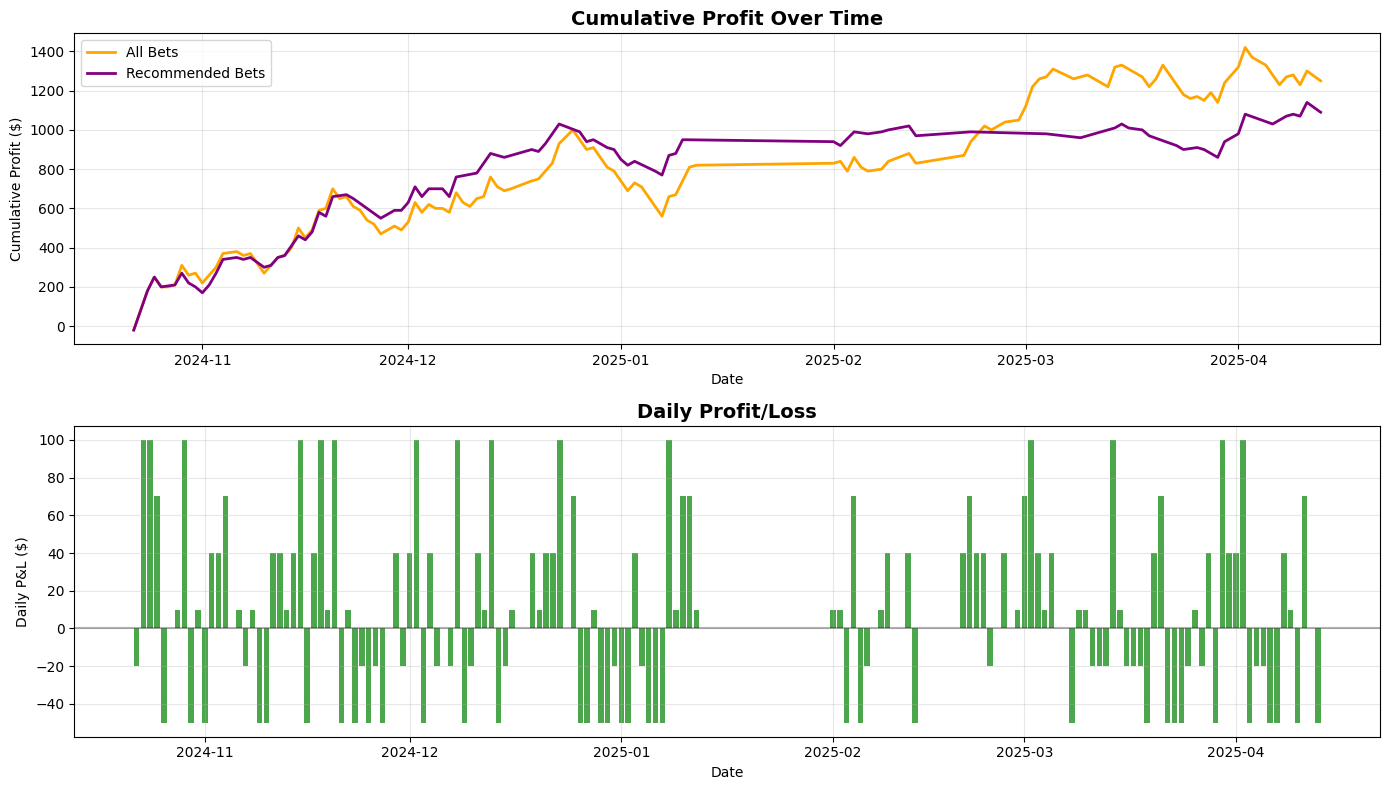

In [100]:
all_metrics = calculatePairMetrics(final_results, stake=10)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=10)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")
    
    # Display probability metrics
    if 'probability_metrics' in all_metrics and 'error' not in all_metrics['probability_metrics']:
        prob_metrics = all_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {prob_metrics.get('n_samples', 'N/A')}")

if rec_metrics:
    print("\n RECOMMENDED BETS ANALYSIS (Edge > 0.20):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")
    
# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()